# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Delos Santos, Mico
- _Student No._: 2024-35117
- _Section_: WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with at most 150 words per question.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=E_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
$$
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + E_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

In [177]:
import math
import numpy as np
import matplotlib.pyplot as plt


In [164]:
h_bar = 6.626*10**(-34)/(2*math.pi)
m = 1
w = 0.8
N = 5
x_pos = np.linspace(-2, 2, num=5)
dx = x_pos[2] - x_pos[1]
V = (1/2)*m*(w**2)*(x_pos)**2

def V_hut(V, N):
    return V*np.eye(N)

def T_hut(N, dx):
    factor = -(h_bar)**2/(2*m*(dx)**2)
    T_mat = (-2*np.eye(N, k=0) + 1*np.eye(N, k=-1) - 1*np.eye(N, k=1))
    return factor * T_mat

def hamiltonian(): 
    return T_hut(N, dx) + V_hut(V, N)

np.linalg.eigh(hamiltonian())

(array([1.11209817e-68, 3.20000000e-01, 3.20000000e-01, 1.28000000e+00,
        1.28000000e+00]),
 array([[0., 0., 0., 1., 0.],
        [0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 1.]]))

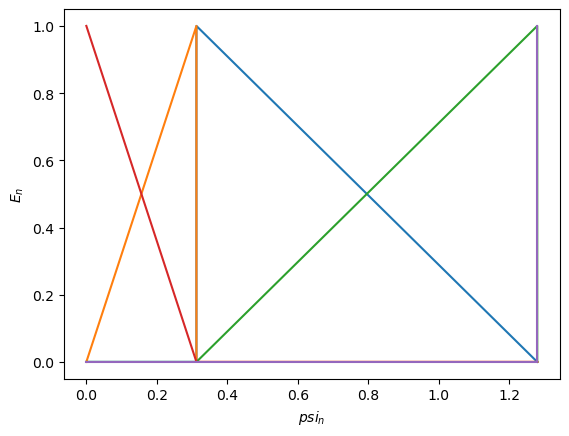

In [178]:
psi_n = [0, 3.2**(-1), 3.2**(-1), 1.28, 1.28]
E_n = ([[0, 0, 0, 1, 0],
        [0, 1, 0, 0, 0],
        [1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 0, 1]])

plt.plot(psi_n, E_n)
plt.xlabel('$psi_n$')
plt.ylabel('$E_n$')
plt.show()

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
E_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

In [70]:
# code here

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)